In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('C:/Users/vanda/Desktop/100-days-ml/day13-toy-project/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.shape

(100, 4)

In [5]:
df=df.iloc[:,1:]

In [6]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [7]:
df.shape

(100, 3)

In [8]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [9]:
import matplotlib.pyplot as plt

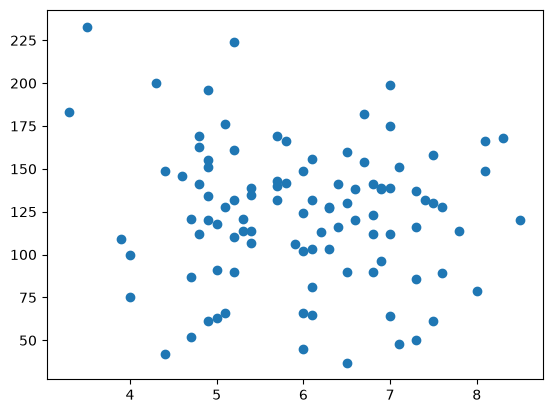

In [10]:
plt.scatter(df['cgpa'],df['iq'])

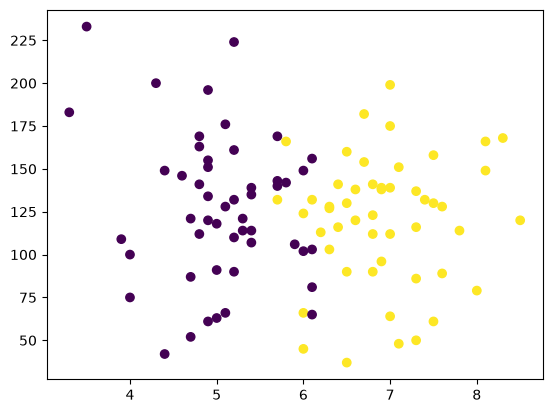

In [11]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement']) #EDA

In [12]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [13]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1)

In [16]:
X_train

,cgpa,iq
63,6.3,128.0
56,6.1,65.0
93,6.8,112.0
21,7.1,151.0
74,6.7,154.0
...,...,...
31,3.9,109.0
25,5.0,91.0
44,7.5,61.0
6,5.7,143.0


In [17]:
y_train

63    1
56    0
93    1
21    1
74    1
     ..
31    0
25    0
44    1
6     0
72    1
Name: placement, Length: 90, dtype: int64

In [18]:
X_test

,cgpa,iq
98,6.3,103.0
57,6.5,130.0
89,4.9,151.0
55,7.8,114.0
43,6.8,141.0
79,6.5,90.0
3,7.4,132.0
9,5.1,66.0
49,5.4,135.0
19,5.2,132.0


In [19]:
y_test

98    1
57    1
89    0
55    1
43    1
79    1
3     1
9     0
49    0
19    0
Name: placement, dtype: int64

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
X_train = scaler.fit_transform(X_train)

In [23]:
X_train

array([[ 2.86806938e-01,  9.63745159e-02],
       [ 1.13567848e-01, -1.43857915e+00],
       [ 7.19904664e-01, -2.93454987e-01],
       [ 9.79763300e-01,  6.56754426e-01],
       [ 6.33285119e-01,  7.29847457e-01],
       [ 6.33285119e-01,  1.41204909e+00],
       [ 2.69483029e-02, -1.41421481e+00],
       [ 2.69483029e-02,  6.08025738e-01],
       [-1.70544260e+00, -5.85827113e-01],
       [ 1.13567848e-01,  1.93831891e-01],
       [-5.79388513e-01, -7.41758914e-02],
       [-5.79388513e-01, -2.44726299e-01],
       [ 4.60046029e-01, -2.12078078e+00],
       [-1.18572533e+00,  5.34932706e-01],
       [ 4.60046029e-01,  8.76033521e-01],
       [ 8.06524209e-01, -6.83284489e-01],
       [-6.66008058e-01, -8.29470552e-01],
       [-1.35896442e+00, -1.99895906e+00],
       [ 1.13567848e-01, -1.04874965e+00],
       [ 2.69483029e-02, -1.92586603e+00],
       [ 3.73426484e-01,  4.13110987e-01],
       [ 1.15300239e+00, -1.80404431e+00],
       [-4.92768968e-01,  3.64382299e-01],
       [-8.

In [25]:
X_test= scaler.transform(X_test)

In [26]:
X_test

array([[ 0.28680694, -0.51273408],
       [ 0.46004603,  0.1451032 ],
       [-0.92586669,  0.65675443],
       [ 1.58610012, -0.2447263 ],
       [ 0.71990466,  0.41311099],
       [ 0.46004603, -0.82947055],
       [ 1.23962193,  0.19383189],
       [-0.7526276 , -1.41421481],
       [-0.49276897,  0.26692492],
       [-0.66600806,  0.19383189]])

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
clf= LogisticRegression()

In [29]:
clf.fit(X_train,y_train) #model training

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [30]:
y_pred= clf.predict(X_test)

In [31]:
y_test

98    1
57    1
89    0
55    1
43    1
79    1
3     1
9     0
49    0
19    0
Name: placement, dtype: int64

In [32]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy_score(y_test,y_pred)

1.0

In [34]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

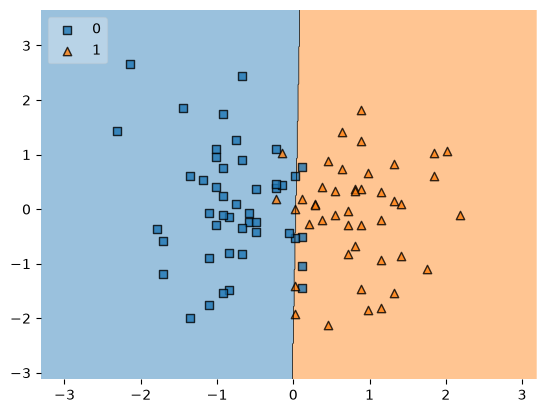

In [35]:
plot_decision_regions(X_train, y_train.values,clf=clf,legend=2)

In [36]:
import pickle

In [37]:
pickle.dump(clf,open('model.pkl','wb'))